# UCI Adult Income Dataset — Preprocessing

This notebook preprocesses `data/adult/adult.data` and saves the result to `data/preprocessed/`.

In [8]:
import sys
import os

# use sys.path to make sure import call current work folder first
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import matplotlib.pyplot as plt
from utils.data_preprocessing import preprocess, preprocess_test, COLUMN_NAMES

## 1. Explore the Raw Data

In [9]:
raw = pd.read_csv('data/adult/adult.data', header=None, names=COLUMN_NAMES, skipinitialspace=True)
print(f'Shape: {raw.shape}')
raw.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [10]:
# Missing values
missing = (raw == '?').sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
workclass         1836
occupation        1843
native_country     583
dtype: int64


Income distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


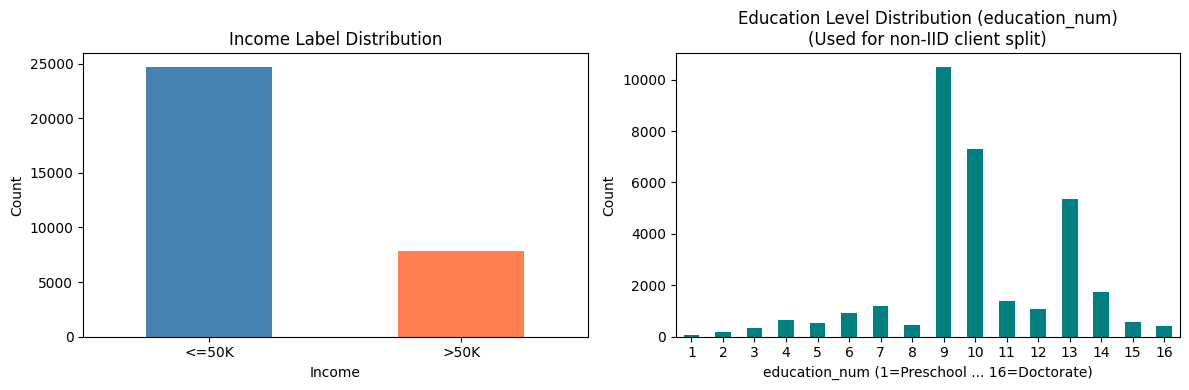

In [11]:
# Label distribution
label_counts = raw['income'].str.strip().value_counts()
print('Income distribution:')
print(label_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label distribution
label_counts.plot(kind='bar', ax=axes[0],  color=['steelblue', 'coral'])
axes[0].set_title('Income Label Distribution')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Education-num distribution (key for non-IID split)
raw['education_num'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Education Level Distribution (education_num)\n(Used for non-IID client split)')
axes[1].set_xlabel('education_num (1=Preschool ... 16=Doctorate)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 2. Preprocess Training Data

In [12]:
df_train, stats = preprocess(
    input_path='data/adult/adult.data',
    output_path='data/preprocessed/adult_preprocessed.csv',
    stats_output_path='data/preprocessed/preprocessing_stats.json',
)

print(f'\nInput dimension: {stats["input_dim"]}')
print(f'Features: {stats["feature_columns"][:5]} ... ({len(stats["feature_columns"])} total)')
df_train.head()

[preprocess] 30162 rows | 87 features | labels: {0: 22654, 1: 7508}
[preprocess] Saved → data/preprocessed/adult_preprocessed.csv
[preprocess] Stats  → data/preprocessed/preprocessing_stats.json

Input dimension: 87
Features: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week'] ... (87 total)


,age,education_num,capital_gain,capital_loss,hours_per_week,label,_edu_num_raw,workclass_Federal-gov,workclass_Local-gov,workclass_Private,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,0.042795,1.128900,0.146090,-0.218582,-0.077733,0,13,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.880274,1.128900,-0.147442,-0.218582,-2.331492,0,13,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.033339,-0.439731,-0.147442,-0.218582,-0.077733,0,9,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,1.108677,-1.224046,-0.147442,-0.218582,-0.077733,0,7,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,-0.794684,1.128900,-0.147442,-0.218582,-0.077733,0,13,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## 3. Preprocess Test Data

In [13]:
df_test = preprocess_test(
    input_path='data/adult/adult.test',
    output_path='data/preprocessed/adult_test_preprocessed.csv',
    stats_path='data/preprocessed/preprocessing_stats.json',
)
print(f'Test shape: {df_test.shape}')
df_test.head()

[preprocess_test] 15060 rows | 87 features | labels: {0: 11360, 1: 3700}
[preprocess_test] Saved → data/preprocessed/adult_test_preprocessed.csv
Test shape: (15060, 88)


,age,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,label
0,-1.023087,-1.224046,-0.147442,-0.218582,-0.077733,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0
1,-0.033339,-0.439731,-0.147442,-0.218582,0.756993,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0
2,-0.794684,0.736742,-0.147442,-0.218582,-0.077733,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,1
3,0.423467,-0.047573,0.890586,-0.218582,-0.077733,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,1
5,-0.337877,-1.616204,-0.147442,-0.218582,-0.912458,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0


## 4. Verify Output

In [14]:
df = pd.read_csv('data/preprocessed/adult_preprocessed.csv')
print(f'Preprocessed shape : {df.shape}')
print(f'Label distribution : {df["label"].value_counts().to_dict()}')
print(f'Label=1 rate       : {df["label"].mean():.3f} ({df["label"].mean()*100:.1f}%)')
print("Data features:", df.columns)
print(f'\nSample (first 3 rows):')
df.head(3)

Preprocessed shape : (30162, 89)
Label distribution : {0: 22654, 1: 7508}
Label=1 rate       : 0.249 (24.9%)
Data features: Index(['age', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week', 'label', '_edu_num_raw', 'workclass_Federal-gov',
       'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'workclass_Without-pay', 'marital_status_Divorced',
       'marital_status_Married-AF-spouse', 'marital_status_Married-civ-spouse',
       'marital_status_Married-spouse-absent', 'marital_status_Never-married',
       'marital_status_Separated', 'marital_status_Widowed',
       'occupation_Adm-clerical', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-special

,age,education_num,capital_gain,capital_loss,hours_per_week,label,_edu_num_raw,workclass_Federal-gov,workclass_Local-gov,workclass_Private,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,0.042795,1.128900,0.146090,-0.218582,-0.077733,0,13,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.880274,1.128900,-0.147442,-0.218582,-2.331492,0,13,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.033339,-0.439731,-0.147442,-0.218582,-0.077733,0,9,False,False,True,...,False,False,False,False,False,False,False,True,False,False
